# Model Tuning


═══════════════════════════════════════════════════════
  CORN
═══════════════════════════════════════════════════════
  Real: 2,108,996  Ablated: 3,207,789
  BallTree neighbors (50 workers)...
  Features: 428
  Optuna: 60 trials (3-fold inner CV)...


  0%|          | 0/60 [00:00<?, ?it/s]

  Best R²: 0.6118  params: {'n_estimators': 1405, 'max_depth': 10, 'learning_rate': 0.041003083183814695, 'subsample': 0.8618626578455605, 'colsample_bytree': 0.657590994420666, 'reg_lambda': 0.25515475109061964, 'reg_alpha': 1.1095690856366274, 'min_child_weight': 17, 'gamma': 0.04902802567538689}
  Final 5-fold CV...
  Fold 1 | R²:0.746 RMSE:24.05 MAPE:10.72% Slope:0.696 | 62.0s
  Fold 2 | R²:0.700 RMSE:25.69 MAPE:12.20% Slope:0.669 | 75.7s
  Fold 3 | R²:0.659 RMSE:27.63 MAPE:11.38% Slope:0.699 | 72.3s
  Fold 4 | R²:0.797 RMSE:21.83 MAPE:10.23% Slope:0.723 | 77.7s
  Fold 5 | R²:0.632 RMSE:29.53 MAPE:13.56% Slope:0.595 | 71.0s
  Saved 2,108,996 rows → data/corn_oof_preds.parquet
  CSV preview  → data/corn_oof_preds.csv
  ✅ R²:0.7067±0.0665  RMSE:25.75  Slope:0.676  Acc:0.7214  (8489.0s)


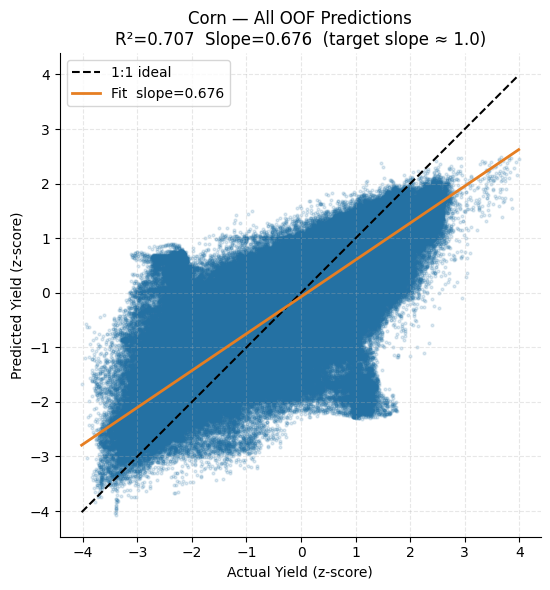

  Slope=0.676  — was ~0.3 before tuning; closer to 1.0 = less shrinkage

═══════════════════════════════════════════════════════
  WHEAT
═══════════════════════════════════════════════════════
  Real: 495,789  Ablated: 800,201
  BallTree neighbors (50 workers)...
  Features: 272
  Optuna: 60 trials (3-fold inner CV)...


  0%|          | 0/60 [00:00<?, ?it/s]

  Best R²: 0.6834  params: {'n_estimators': 1281, 'max_depth': 10, 'learning_rate': 0.034584117216420227, 'subsample': 0.7344228183347605, 'colsample_bytree': 0.619162737625482, 'reg_lambda': 0.366467387337254, 'reg_alpha': 1.5931290083924974, 'min_child_weight': 4, 'gamma': 0.07837717400403532}
  Final 5-fold CV...
  Fold 1 | R²:0.874 RMSE:8.95 MAPE:15.03% Slope:0.794 | 15.9s
  Fold 2 | R²:0.816 RMSE:9.67 MAPE:9.46% Slope:0.782 | 15.0s
  Fold 3 | R²:0.874 RMSE:8.79 MAPE:8.41% Slope:0.783 | 16.3s
  Fold 4 | R²:0.680 RMSE:11.58 MAPE:11.20% Slope:0.670 | 15.7s
  Fold 5 | R²:0.862 RMSE:7.34 MAPE:7.57% Slope:0.823 | 16.1s
  Saved 495,789 rows → data/wheat_oof_preds.parquet
  CSV preview  → data/wheat_oof_preds.csv
  ✅ R²:0.8213±0.0824  RMSE:9.27  Slope:0.771  Acc:0.7466  (1478.2s)


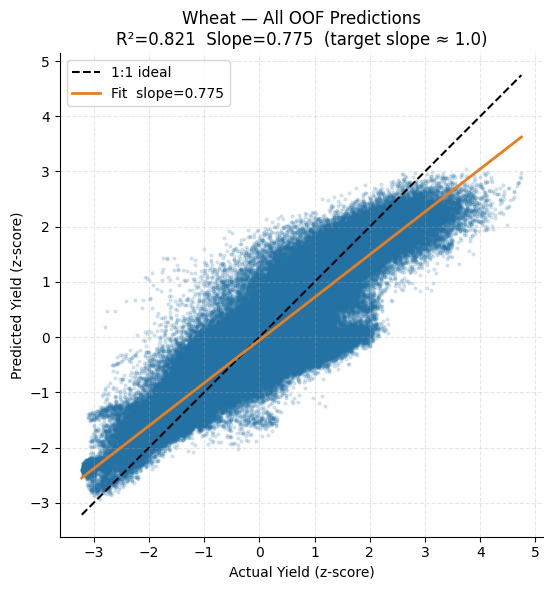

  Slope=0.775  — was ~0.3 before tuning; closer to 1.0 = less shrinkage

═══════════════════════════════════════════════════════
  SOYBEAN
═══════════════════════════════════════════════════════
  Real: 694,250  Ablated: 1,307,054
  BallTree neighbors (50 workers)...
  Features: 428
  Optuna: 60 trials (3-fold inner CV)...


  0%|          | 0/60 [00:00<?, ?it/s]

[W 2026-03-04 21:29:13,724] Trial 55 failed with parameters: {'n_estimators': 1133, 'max_depth': 10, 'learning_rate': 0.02645876072569885, 'subsample': 0.5442961355141167, 'colsample_bytree': 0.6253894598506264, 'reg_lambda': 0.2536325239415106, 'reg_alpha': 1.8128964154558398, 'min_child_weight': 22, 'gamma': 0.06527993636870257} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/mnt/home/arnabdev/.conda/envs/sar_project_env/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_1293364/1453815742.py", line 154, in objective
    m.fit(X[tr], y[tr]/mu_tr,
    ~~~~~^^^^^^^^^^^^^^^^^^^^
          eval_set=[(X[real_te], y[real_te]/mu_te)], verbose=False)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/home/arnabdev/.conda/envs/sar_project_env/lib/python3.14/site-packages/xgboost/core.py", line 774, in inner_f
    return func(**kw

KeyboardInterrupt: 

In [1]:
"""
train_all_crops.py
Single GPU + multi-core CPU. Just run this cell. No subprocesses, no pickling.
"""

import os, time, warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, mean_absolute_percentage_error)
from sklearn.neighbors import BallTree

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG  ← only thing you ever need to edit
# ══════════════════════════════════════════════════════════════════════════════
ABLATED_PATH    = "data/gamma_k8_stacked_ablated_corn_wheat_soy.parquet"
TOTAL_CPUS      = int(os.environ.get("SLURM_CPUS_PER_TASK", 100))
N_OPTUNA_TRIALS = 60
OPTUNA_CV_FOLDS = 3
FINAL_CV_FOLDS  = 5
RANDOM_STATE    = 42

PRED_COL        = "pred_yield_oof"
PRED_RATIO_COL  = "pred_yield_ratio_oof"
PRED_FOLD_COL   = "pred_fold"

CROP_CONFIGS = [
    ("Corn",    "data/corn_2016_2023_processed.parquet",
                "data/corn_oof_preds.parquet",     "corn"),
    ("Wheat",   "data/wheat_2016_2023_processed.parquet",
                "data/wheat_oof_preds.parquet",    "wheat"),
    ("Soybean", "data/soybeans_2016_2023_processed.parquet",
                "data/soybeans_oof_preds.parquet", "soybean"),
]

# CPU split: half for BallTree parallelism, half for XGBoost threading
BALLTREE_JOBS = max(1, TOTAL_CPUS // 2)
XGB_NTHREAD   = max(1, TOTAL_CPUS - BALLTREE_JOBS)

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def load_and_combine(orig_path, abl_filter):
    df_orig = pd.read_parquet(orig_path)
    df_orig.columns = [c.lower() for c in df_orig.columns]
    df_orig = df_orig[df_orig["yield"].notna()].copy()
    df_orig["is_ablation"] = False

    df_abl = pd.read_parquet(ABLATED_PATH)
    df_abl.columns = [c.lower() for c in df_abl.columns]
    df_abl = df_abl[
        df_abl["crop"].str.contains(abl_filter, case=False, na=False) &
        df_abl["year"].isin(df_orig["year"].unique())
    ].copy()
    df_abl["is_ablation"] = True
    df_abl["farm_name"] = df_abl["farm_name"].map(
        {n: f"abl_{i}" for i, n in enumerate(df_abl["farm_name"].unique())}
    )

    common = sorted(set(df_orig.columns) & set(df_abl.columns))
    common = [c for c in common if c != "is_ablation"] + ["is_ablation"]
    df = pd.concat([df_orig[common], df_abl[common]]).reset_index(drop=True)
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"  Real: {len(df_orig):,}  Ablated: {len(df_abl):,}")
    return df


def _balltree_farm(task):
    idx, coords, vals, k = task
    if len(idx) <= k:
        return idx, None
    _, nbrs = BallTree(coords).query(coords, k=k + 1)
    return idx, np.stack([vals[:, j][nbrs[:, 1:]].mean(1)
                          for j in range(vals.shape[1])], axis=1)


def build_features(df):
    SAR_RAW  = [c for c in df.columns
                if (c.startswith("vv_") or c.startswith("vh_"))
                and not c.endswith("_2")]
    SAR_IDX  = [c for c in df.columns if c.startswith(("pr_", "rvi_"))]
    WEATHER  = [c for c in df.columns
                if any(k in c for k in ["prcp_","srad_","gdd_"])
                and "_season" not in c]
    TERRAIN  = ["dem","slope_deg","aspect_deg","shape_index"]
    SOIL     = [c for c in df.columns if c.startswith("soil_")]
    SAR_ALL  = SAR_RAW + SAR_IDX

    # Field-level means
    fm = df.groupby(["farm_name","year"])[SAR_ALL].transform("mean").astype(np.float32)
    fm.columns = [f"{c}_field_mean" for c in fm.columns]
    df = pd.concat([df, fm], axis=1)

    # BallTree neighbors — parallel across farms
    print(f"  BallTree neighbors ({BALLTREE_JOBS} workers)...")
    nd = np.zeros((len(df), len(SAR_ALL)), dtype=np.float32)
    tasks = [
        (np.where((df["farm_name"] == farm).to_numpy())[0],
         df.loc[df["farm_name"] == farm, ["latitude","longitude"]].to_numpy(),
         df.loc[df["farm_name"] == farm, SAR_ALL].to_numpy(dtype=np.float32), 8)
        for farm in df["farm_name"].unique()
    ]
    for idx, result in Parallel(n_jobs=BALLTREE_JOBS, backend="loky")(
        delayed(_balltree_farm)(t) for t in tasks
    ):
        if result is not None:
            nd[idx] = result

    nb_cols = [f"{c}_neighbor_8" for c in SAR_ALL]
    df = pd.concat([df, pd.DataFrame(nd, columns=nb_cols, index=df.index)], axis=1)

    FEATURES = SAR_ALL + list(fm.columns) + nb_cols + WEATHER + TERRAIN + SOIL + ["year","latitude"]
    print(f"  Features: {len(FEATURES)}")
    return df, FEATURES


def make_objective(X, y, groups, years, is_ablation, y_binned):
    def objective(trial):
        params = dict(
            tree_method      = "hist",
            device           = "cuda",
            nthread          = XGB_NTHREAD,
            n_estimators     = trial.suggest_int("n_estimators", 400, 1500),
            max_depth        = trial.suggest_int("max_depth", 4, 10),
            learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            subsample        = trial.suggest_float("subsample", 0.5, 0.95),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.4, 0.9),
            reg_lambda       = trial.suggest_float("reg_lambda", 0.1, 5.0, log=True),
            reg_alpha        = trial.suggest_float("reg_alpha", 0.0, 2.0),
            min_child_weight = trial.suggest_int("min_child_weight", 1, 30),
            gamma            = trial.suggest_float("gamma", 0.0, 1.0),
            random_state     = RANDOM_STATE,
            early_stopping_rounds = 40,
        )
        scores = []
        for tr, te in StratifiedGroupKFold(
                n_splits=OPTUNA_CV_FOLDS, shuffle=True,
                random_state=RANDOM_STATE).split(X, y_binned, groups):
            real_te = te[~is_ablation[te]]
            if not len(real_te): continue
            yr_map = {yr: y[tr][years[tr]==yr].mean() for yr in np.unique(years[tr])}
            gm     = float(y[tr].mean())
            mu_tr  = np.array([yr_map.get(yr, gm) for yr in years[tr]])
            mu_te  = np.array([yr_map.get(yr, gm) for yr in years[real_te]])
            m = xgb.XGBRegressor(**params)
            m.fit(X[tr], y[tr]/mu_tr,
                  eval_set=[(X[real_te], y[real_te]/mu_te)], verbose=False)
            scores.append(r2_score(y[real_te], m.predict(X[real_te]) * mu_te))
        return float(np.mean(scores)) if scores else -999.0
    return objective


# ══════════════════════════════════════════════════════════════════════════════
# MAIN LOOP
# ══════════════════════════════════════════════════════════════════════════════
all_summary = {}
wall_start  = time.time()

for crop_name, orig_path, out_path, abl_filter in CROP_CONFIGS:
    print(f"\n{'═'*55}\n  {crop_name.upper()}\n{'═'*55}")
    t0 = time.time()

    df = load_and_combine(orig_path, abl_filter)
    df, FEATURES = build_features(df)

    X           = df[FEATURES].to_numpy(dtype=np.float32)
    y           = df["yield"].to_numpy(dtype=np.float32)
    groups      = df["farm_name"].astype(str).to_numpy()
    years       = df["year"].to_numpy()
    is_ablation = df["is_ablation"].to_numpy().astype(bool)

    real_mask        = ~is_ablation
    y_binned         = np.full(len(y), -1, dtype=int)
    y_binned[real_mask] = pd.qcut(
        y[real_mask], q=5, labels=False, duplicates="drop").astype(int)

    # ── Optuna ────────────────────────────────────────────────────────────────
    print(f"  Optuna: {N_OPTUNA_TRIALS} trials ({OPTUNA_CV_FOLDS}-fold inner CV)...")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(
        make_objective(X, y, groups, years, is_ablation, y_binned),
        n_trials=N_OPTUNA_TRIALS,
        show_progress_bar=True,
    )
    best = study.best_params
    print(f"  Best R²: {study.best_value:.4f}  params: {best}")

    # ── Final 5-fold CV ───────────────────────────────────────────────────────
    print(f"  Final {FINAL_CV_FOLDS}-fold CV...")
    final_params = dict(tree_method="hist", device="cuda",
                        nthread=XGB_NTHREAD, random_state=RANDOM_STATE,
                        early_stopping_rounds=50, **best)

    df[PRED_COL] = df[PRED_RATIO_COL] = df[PRED_FOLD_COL] = np.nan
    results = []

    for k, (tr, te) in enumerate(
        StratifiedGroupKFold(n_splits=FINAL_CV_FOLDS, shuffle=True,
                             random_state=RANDOM_STATE
                             ).split(X, y_binned, groups), 1):
        fs      = time.time()
        real_te = te[~is_ablation[te]]
        if not len(real_te): continue

        yr_map = df.iloc[tr].groupby("year")["yield"].mean().to_dict()
        gm     = float(y[tr].mean())
        mu_tr  = pd.Series(years[tr]).map(yr_map).fillna(gm).values
        mu_te  = pd.Series(years[real_te]).map(yr_map).fillna(gm).values

        model  = xgb.XGBRegressor(**final_params)
        model.fit(X[tr], y[tr]/mu_tr,
                  eval_set=[(X[real_te], y[real_te]/mu_te)], verbose=False)

        p_ratio = model.predict(X[real_te])
        p_raw   = p_ratio * mu_te

        df.loc[real_te, PRED_COL]       = p_raw.astype(np.float32)
        df.loc[real_te, PRED_RATIO_COL] = p_ratio.astype(np.float32)
        df.loc[real_te, PRED_FOLD_COL]  = k

        r2    = r2_score(y[real_te], p_raw)
        mae   = mean_absolute_error(y[real_te], p_raw)
        rmse  = float(np.sqrt(mean_squared_error(y[real_te], p_raw)))
        mape  = mean_absolute_percentage_error(y[real_te], p_raw) * 100
        nrmse = rmse / (y[real_te].max() - y[real_te].min()) * 100
        zt    = np.where(y[real_te]/mu_te<0.9, 0, np.where(y[real_te]/mu_te<=1.1, 1, 2))
        zp    = np.where(p_ratio<0.9, 0, np.where(p_ratio<=1.1, 1, 2))

        # Slope of fit line on z-score scatter (key shrinkage diagnostic)
        mu_all = y[real_te].mean(); sd_all = y[real_te].std()
        sd_all = sd_all if sd_all > 0 else 1.0
        yt_z   = (y[real_te]  - mu_all) / sd_all
        yp_z   = (p_raw - mu_all) / sd_all
        slope  = float(np.polyfit(yt_z, yp_z, 1)[0])

        results.append({"R2":r2,"MAE":mae,"RMSE":rmse,"NRMSE":nrmse,
                        "MAPE":mape,"Zone_Acc":(zt==zp).mean(),"Slope":slope})
        print(f"  Fold {k} | R²:{r2:.3f} RMSE:{rmse:.2f} "
              f"MAPE:{mape:.2f}% Slope:{slope:.3f} | {time.time()-fs:.1f}s")

    res = pd.DataFrame(results)
    all_summary[crop_name] = res

    # Save real rows only (parquet — contains all original cols + 3 pred cols)
    df_out = df[~is_ablation & df[PRED_COL].notna()].copy()
    df_out  = df_out.loc[:, ~df_out.columns.duplicated()]
    df_out.to_parquet(out_path, index=False)

    # Also save a lightweight CSV with just the key columns for quick inspection
    csv_path = out_path.replace(".parquet", ".csv")
    df_out[["farm_name","year","yield", PRED_COL, PRED_RATIO_COL, PRED_FOLD_COL]].to_csv(csv_path, index=False)

    print(f"  Saved {len(df_out):,} rows → {out_path}")
    print(f"  CSV preview  → {csv_path}")
    print(f"  ✅ R²:{res['R2'].mean():.4f}±{res['R2'].std():.4f}  "
          f"RMSE:{res['RMSE'].mean():.2f}  "
          f"Slope:{res['Slope'].mean():.3f}  "
          f"Acc:{res['Zone_Acc'].mean():.4f}  "
          f"({time.time()-t0:.1f}s)")

    # ── Scatter plot: shows fit-line slope immediately after each crop ────────
    import matplotlib.pyplot as plt
    _ya  = df_out["yield"].to_numpy(dtype=float)
    _yp  = df_out[PRED_COL].to_numpy(dtype=float)
    _mu  = _ya.mean();  _sd = _ya.std() or 1.0
    _yz  = (_ya - _mu) / _sd   # actual z-scores
    _pz  = (_yp - _mu) / _sd   # predicted z-scores
    _m, _b = np.polyfit(_yz, _pz, 1)
    _lo, _hi = _yz.min(), _yz.max()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(_yz, _pz, s=4, alpha=0.15, color="#2471A3", rasterized=True)
    ax.plot([_lo, _hi], [_lo, _hi],                  "k--", lw=1.5, label="1:1 ideal")
    ax.plot([_lo, _hi], [_m*_lo+_b, _m*_hi+_b],
            color="#E67E22", lw=2, label=f"Fit  slope={_m:.3f}")
    ax.set_xlabel("Actual Yield (z-score)")
    ax.set_ylabel("Predicted Yield (z-score)")
    ax.set_title(f"{crop_name} — All OOF Predictions\n"
                 f"R²={res['R2'].mean():.3f}  Slope={_m:.3f}  "
                 f"(target slope ≈ 1.0)")
    ax.legend(fontsize=10)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3, linestyle="--")
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    plt.tight_layout()
    plt.show()
    print(f"  Slope={_m:.3f}  — was ~0.3 before tuning; closer to 1.0 = less shrinkage")

# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*65}")
print(f"  FINAL SUMMARY  (total wall time: {time.time()-wall_start:.1f}s)")
print(f"{'═'*65}")
print(f"  {'Crop':<10} {'R²':>14} {'MAE':>8} {'RMSE':>8} "
      f"{'NRMSE':>7} {'MAPE':>7} {'Slope':>7} {'ZoneAcc':>9}")
print(f"  {'-'*68}")
for crop, r in all_summary.items():
    print(f"  {crop:<10} "
          f"{r['R2'].mean():.4f}±{r['R2'].std():.4f}  "
          f"{r['MAE'].mean():>7.2f}  "
          f"{r['RMSE'].mean():>7.2f}  "
          f"{r['NRMSE'].mean():>6.2f}%  "
          f"{r['MAPE'].mean():>6.2f}%  "
          f"{r['Slope'].mean():>6.3f}  "
          f"{r['Zone_Acc'].mean():>8.4f}")
print(f"  {'-'*68}")
print("  Slope target = 1.0  |  your baseline was ~0.26-0.41  |  goal > 0.7")


═══════════════════════════════════════════════════════
  SOYBEAN
═══════════════════════════════════════════════════════
  Real: 694,250  Ablated: 1,307,054
  BallTree neighbors (50 workers)...
  Features: 428
  Optuna: 60 trials (3-fold inner CV)...


  0%|          | 0/60 [00:00<?, ?it/s]

  Best R²: 0.6652  params: {'n_estimators': 1165, 'max_depth': 10, 'learning_rate': 0.024695301006348563, 'subsample': 0.6381493450521268, 'colsample_bytree': 0.6565860338592727, 'reg_lambda': 0.8107304708439549, 'reg_alpha': 1.8770089628604596, 'min_child_weight': 17, 'gamma': 0.06560554134422797}
  Final 5-fold CV...
  Fold 1 | R²:0.840 RMSE:5.65 MAPE:10.33% Slope:0.794 | 28.1s
  Fold 2 | R²:0.823 RMSE:5.66 MAPE:9.21% Slope:0.763 | 29.0s
  Fold 3 | R²:0.682 RMSE:7.97 MAPE:13.16% Slope:0.708 | 25.9s
  Fold 4 | R²:0.817 RMSE:5.86 MAPE:9.27% Slope:0.748 | 28.8s
  Fold 5 | R²:0.712 RMSE:7.14 MAPE:10.72% Slope:0.712 | 28.8s
  Saved 694,250 rows → data/soybeans_oof_preds.parquet
  CSV preview  → data/soybeans_oof_preds.csv
  ✅ R²:0.7752±0.0723  RMSE:6.46  Slope:0.745  Acc:0.7028  (3269.4s)


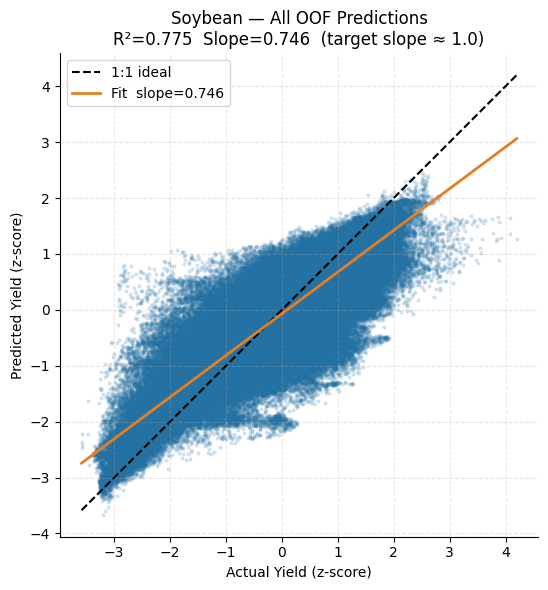

  Slope=0.746  — was ~0.3 before tuning; closer to 1.0 = less shrinkage

═════════════════════════════════════════════════════════════════
  FINAL SUMMARY  (total wall time: 3271.8s)
═════════════════════════════════════════════════════════════════
  Crop                   R²      MAE     RMSE   NRMSE    MAPE   Slope   ZoneAcc
  --------------------------------------------------------------------
  Soybean    0.7752±0.0723     4.72     6.46    6.78%   10.54%   0.745    0.7028
  --------------------------------------------------------------------
  Slope target = 1.0  |  your baseline was ~0.26-0.41  |  goal > 0.7


In [1]:
"""
train_all_crops.py
Single GPU + multi-core CPU. Just run this cell. No subprocesses, no pickling.
"""

import os, time, warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, mean_absolute_percentage_error)
from sklearn.neighbors import BallTree

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG  ← only thing you ever need to edit
# ══════════════════════════════════════════════════════════════════════════════
ABLATED_PATH    = "data/gamma_k8_stacked_ablated_corn_wheat_soy.parquet"
TOTAL_CPUS      = int(os.environ.get("SLURM_CPUS_PER_TASK", 100))
N_OPTUNA_TRIALS = 60
OPTUNA_CV_FOLDS = 3
FINAL_CV_FOLDS  = 5
RANDOM_STATE    = 42

PRED_COL        = "pred_yield_oof"
PRED_RATIO_COL  = "pred_yield_ratio_oof"
PRED_FOLD_COL   = "pred_fold"

CROP_CONFIGS = [
    ("Soybean", "data/soybeans_2016_2023_processed.parquet",
                "data/soybeans_oof_preds.parquet", "soybean"),
]

# CPU split: half for BallTree parallelism, half for XGBoost threading
BALLTREE_JOBS = max(1, TOTAL_CPUS // 2)
XGB_NTHREAD   = max(1, TOTAL_CPUS - BALLTREE_JOBS)

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def load_and_combine(orig_path, abl_filter):
    df_orig = pd.read_parquet(orig_path)
    df_orig.columns = [c.lower() for c in df_orig.columns]
    df_orig = df_orig[df_orig["yield"].notna()].copy()
    df_orig["is_ablation"] = False

    df_abl = pd.read_parquet(ABLATED_PATH)
    df_abl.columns = [c.lower() for c in df_abl.columns]
    df_abl = df_abl[
        df_abl["crop"].str.contains(abl_filter, case=False, na=False) &
        df_abl["year"].isin(df_orig["year"].unique())
    ].copy()
    df_abl["is_ablation"] = True
    df_abl["farm_name"] = df_abl["farm_name"].map(
        {n: f"abl_{i}" for i, n in enumerate(df_abl["farm_name"].unique())}
    )

    common = sorted(set(df_orig.columns) & set(df_abl.columns))
    common = [c for c in common if c != "is_ablation"] + ["is_ablation"]
    df = pd.concat([df_orig[common], df_abl[common]]).reset_index(drop=True)
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"  Real: {len(df_orig):,}  Ablated: {len(df_abl):,}")
    return df


def _balltree_farm(task):
    idx, coords, vals, k = task
    if len(idx) <= k:
        return idx, None
    _, nbrs = BallTree(coords).query(coords, k=k + 1)
    return idx, np.stack([vals[:, j][nbrs[:, 1:]].mean(1)
                          for j in range(vals.shape[1])], axis=1)


def build_features(df):
    SAR_RAW  = [c for c in df.columns
                if (c.startswith("vv_") or c.startswith("vh_"))
                and not c.endswith("_2")]
    SAR_IDX  = [c for c in df.columns if c.startswith(("pr_", "rvi_"))]
    WEATHER  = [c for c in df.columns
                if any(k in c for k in ["prcp_","srad_","gdd_"])
                and "_season" not in c]
    TERRAIN  = ["dem","slope_deg","aspect_deg","shape_index"]
    SOIL     = [c for c in df.columns if c.startswith("soil_")]
    SAR_ALL  = SAR_RAW + SAR_IDX

    # Field-level means
    fm = df.groupby(["farm_name","year"])[SAR_ALL].transform("mean").astype(np.float32)
    fm.columns = [f"{c}_field_mean" for c in fm.columns]
    df = pd.concat([df, fm], axis=1)

    # BallTree neighbors — parallel across farms
    print(f"  BallTree neighbors ({BALLTREE_JOBS} workers)...")
    nd = np.zeros((len(df), len(SAR_ALL)), dtype=np.float32)
    tasks = [
        (np.where((df["farm_name"] == farm).to_numpy())[0],
         df.loc[df["farm_name"] == farm, ["latitude","longitude"]].to_numpy(),
         df.loc[df["farm_name"] == farm, SAR_ALL].to_numpy(dtype=np.float32), 8)
        for farm in df["farm_name"].unique()
    ]
    for idx, result in Parallel(n_jobs=BALLTREE_JOBS, backend="loky")(
        delayed(_balltree_farm)(t) for t in tasks
    ):
        if result is not None:
            nd[idx] = result

    nb_cols = [f"{c}_neighbor_8" for c in SAR_ALL]
    df = pd.concat([df, pd.DataFrame(nd, columns=nb_cols, index=df.index)], axis=1)

    FEATURES = SAR_ALL + list(fm.columns) + nb_cols + WEATHER + TERRAIN + SOIL + ["year","latitude"]
    print(f"  Features: {len(FEATURES)}")
    return df, FEATURES


def make_objective(X, y, groups, years, is_ablation, y_binned):
    def objective(trial):
        params = dict(
            tree_method      = "hist",
            device           = "cuda",
            nthread          = XGB_NTHREAD,
            n_estimators     = trial.suggest_int("n_estimators", 400, 1500),
            max_depth        = trial.suggest_int("max_depth", 4, 10),
            learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            subsample        = trial.suggest_float("subsample", 0.5, 0.95),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.4, 0.9),
            reg_lambda       = trial.suggest_float("reg_lambda", 0.1, 5.0, log=True),
            reg_alpha        = trial.suggest_float("reg_alpha", 0.0, 2.0),
            min_child_weight = trial.suggest_int("min_child_weight", 1, 30),
            gamma            = trial.suggest_float("gamma", 0.0, 1.0),
            random_state     = RANDOM_STATE,
            early_stopping_rounds = 40,
        )
        scores = []
        for tr, te in StratifiedGroupKFold(
                n_splits=OPTUNA_CV_FOLDS, shuffle=True,
                random_state=RANDOM_STATE).split(X, y_binned, groups):
            real_te = te[~is_ablation[te]]
            if not len(real_te): continue
            yr_map = {yr: y[tr][years[tr]==yr].mean() for yr in np.unique(years[tr])}
            gm     = float(y[tr].mean())
            mu_tr  = np.array([yr_map.get(yr, gm) for yr in years[tr]])
            mu_te  = np.array([yr_map.get(yr, gm) for yr in years[real_te]])
            m = xgb.XGBRegressor(**params)
            m.fit(X[tr], y[tr]/mu_tr,
                  eval_set=[(X[real_te], y[real_te]/mu_te)], verbose=False)
            scores.append(r2_score(y[real_te], m.predict(X[real_te]) * mu_te))
        return float(np.mean(scores)) if scores else -999.0
    return objective


# ══════════════════════════════════════════════════════════════════════════════
# MAIN LOOP
# ══════════════════════════════════════════════════════════════════════════════
all_summary = {}
wall_start  = time.time()

for crop_name, orig_path, out_path, abl_filter in CROP_CONFIGS:
    print(f"\n{'═'*55}\n  {crop_name.upper()}\n{'═'*55}")
    t0 = time.time()

    df = load_and_combine(orig_path, abl_filter)
    df, FEATURES = build_features(df)

    X           = df[FEATURES].to_numpy(dtype=np.float32)
    y           = df["yield"].to_numpy(dtype=np.float32)
    groups      = df["farm_name"].astype(str).to_numpy()
    years       = df["year"].to_numpy()
    is_ablation = df["is_ablation"].to_numpy().astype(bool)

    real_mask        = ~is_ablation
    y_binned         = np.full(len(y), -1, dtype=int)
    y_binned[real_mask] = pd.qcut(
        y[real_mask], q=5, labels=False, duplicates="drop").astype(int)

    # ── Optuna ────────────────────────────────────────────────────────────────
    print(f"  Optuna: {N_OPTUNA_TRIALS} trials ({OPTUNA_CV_FOLDS}-fold inner CV)...")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(
        make_objective(X, y, groups, years, is_ablation, y_binned),
        n_trials=N_OPTUNA_TRIALS,
        show_progress_bar=True,
    )
    best = study.best_params
    print(f"  Best R²: {study.best_value:.4f}  params: {best}")

    # ── Final 5-fold CV ───────────────────────────────────────────────────────
    print(f"  Final {FINAL_CV_FOLDS}-fold CV...")
    final_params = dict(tree_method="hist", device="cuda",
                        nthread=XGB_NTHREAD, random_state=RANDOM_STATE,
                        early_stopping_rounds=50, **best)

    df[PRED_COL] = df[PRED_RATIO_COL] = df[PRED_FOLD_COL] = np.nan
    results = []

    for k, (tr, te) in enumerate(
        StratifiedGroupKFold(n_splits=FINAL_CV_FOLDS, shuffle=True,
                             random_state=RANDOM_STATE
                             ).split(X, y_binned, groups), 1):
        fs      = time.time()
        real_te = te[~is_ablation[te]]
        if not len(real_te): continue

        yr_map = df.iloc[tr].groupby("year")["yield"].mean().to_dict()
        gm     = float(y[tr].mean())
        mu_tr  = pd.Series(years[tr]).map(yr_map).fillna(gm).values
        mu_te  = pd.Series(years[real_te]).map(yr_map).fillna(gm).values

        model  = xgb.XGBRegressor(**final_params)
        model.fit(X[tr], y[tr]/mu_tr,
                  eval_set=[(X[real_te], y[real_te]/mu_te)], verbose=False)

        p_ratio = model.predict(X[real_te])
        p_raw   = p_ratio * mu_te

        df.loc[real_te, PRED_COL]       = p_raw.astype(np.float32)
        df.loc[real_te, PRED_RATIO_COL] = p_ratio.astype(np.float32)
        df.loc[real_te, PRED_FOLD_COL]  = k

        r2    = r2_score(y[real_te], p_raw)
        mae   = mean_absolute_error(y[real_te], p_raw)
        rmse  = float(np.sqrt(mean_squared_error(y[real_te], p_raw)))
        mape  = mean_absolute_percentage_error(y[real_te], p_raw) * 100
        nrmse = rmse / (y[real_te].max() - y[real_te].min()) * 100
        zt    = np.where(y[real_te]/mu_te<0.9, 0, np.where(y[real_te]/mu_te<=1.1, 1, 2))
        zp    = np.where(p_ratio<0.9, 0, np.where(p_ratio<=1.1, 1, 2))

        # Slope of fit line on z-score scatter (key shrinkage diagnostic)
        mu_all = y[real_te].mean(); sd_all = y[real_te].std()
        sd_all = sd_all if sd_all > 0 else 1.0
        yt_z   = (y[real_te]  - mu_all) / sd_all
        yp_z   = (p_raw - mu_all) / sd_all
        slope  = float(np.polyfit(yt_z, yp_z, 1)[0])

        results.append({"R2":r2,"MAE":mae,"RMSE":rmse,"NRMSE":nrmse,
                        "MAPE":mape,"Zone_Acc":(zt==zp).mean(),"Slope":slope})
        print(f"  Fold {k} | R²:{r2:.3f} RMSE:{rmse:.2f} "
              f"MAPE:{mape:.2f}% Slope:{slope:.3f} | {time.time()-fs:.1f}s")

    res = pd.DataFrame(results)
    all_summary[crop_name] = res

    # Save real rows only (parquet — contains all original cols + 3 pred cols)
    df_out = df[~is_ablation & df[PRED_COL].notna()].copy()
    df_out  = df_out.loc[:, ~df_out.columns.duplicated()]
    df_out.to_parquet(out_path, index=False)

    # Also save a lightweight CSV with just the key columns for quick inspection
    csv_path = out_path.replace(".parquet", ".csv")
    df_out[["farm_name","year","yield", PRED_COL, PRED_RATIO_COL, PRED_FOLD_COL]].to_csv(csv_path, index=False)

    print(f"  Saved {len(df_out):,} rows → {out_path}")
    print(f"  CSV preview  → {csv_path}")
    print(f"  ✅ R²:{res['R2'].mean():.4f}±{res['R2'].std():.4f}  "
          f"RMSE:{res['RMSE'].mean():.2f}  "
          f"Slope:{res['Slope'].mean():.3f}  "
          f"Acc:{res['Zone_Acc'].mean():.4f}  "
          f"({time.time()-t0:.1f}s)")

    # ── Scatter plot: shows fit-line slope immediately after each crop ────────
    import matplotlib.pyplot as plt
    _ya  = df_out["yield"].to_numpy(dtype=float)
    _yp  = df_out[PRED_COL].to_numpy(dtype=float)
    _mu  = _ya.mean();  _sd = _ya.std() or 1.0
    _yz  = (_ya - _mu) / _sd   # actual z-scores
    _pz  = (_yp - _mu) / _sd   # predicted z-scores
    _m, _b = np.polyfit(_yz, _pz, 1)
    _lo, _hi = _yz.min(), _yz.max()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(_yz, _pz, s=4, alpha=0.15, color="#2471A3", rasterized=True)
    ax.plot([_lo, _hi], [_lo, _hi],                  "k--", lw=1.5, label="1:1 ideal")
    ax.plot([_lo, _hi], [_m*_lo+_b, _m*_hi+_b],
            color="#E67E22", lw=2, label=f"Fit  slope={_m:.3f}")
    ax.set_xlabel("Actual Yield (z-score)")
    ax.set_ylabel("Predicted Yield (z-score)")
    ax.set_title(f"{crop_name} — All OOF Predictions\n"
                 f"R²={res['R2'].mean():.3f}  Slope={_m:.3f}  "
                 f"(target slope ≈ 1.0)")
    ax.legend(fontsize=10)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3, linestyle="--")
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    plt.tight_layout()
    plt.show()
    print(f"  Slope={_m:.3f}  — was ~0.3 before tuning; closer to 1.0 = less shrinkage")

# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*65}")
print(f"  FINAL SUMMARY  (total wall time: {time.time()-wall_start:.1f}s)")
print(f"{'═'*65}")
print(f"  {'Crop':<10} {'R²':>14} {'MAE':>8} {'RMSE':>8} "
      f"{'NRMSE':>7} {'MAPE':>7} {'Slope':>7} {'ZoneAcc':>9}")
print(f"  {'-'*68}")
for crop, r in all_summary.items():
    print(f"  {crop:<10} "
          f"{r['R2'].mean():.4f}±{r['R2'].std():.4f}  "
          f"{r['MAE'].mean():>7.2f}  "
          f"{r['RMSE'].mean():>7.2f}  "
          f"{r['NRMSE'].mean():>6.2f}%  "
          f"{r['MAPE'].mean():>6.2f}%  "
          f"{r['Slope'].mean():>6.3f}  "
          f"{r['Zone_Acc'].mean():>8.4f}")
print(f"  {'-'*68}")
print("  Slope target = 1.0  |  your baseline was ~0.26-0.41  |  goal > 0.7")

# Model Plotting

  Corn | All Years | 2,108,996 pixels
    R²=0.708  RMSE=25.86  MAE=18.08  Bias=-3.54  Slope=0.676  ZoneAcc=0.713
  Saved → actual_vs_pred_corn_all_years.png


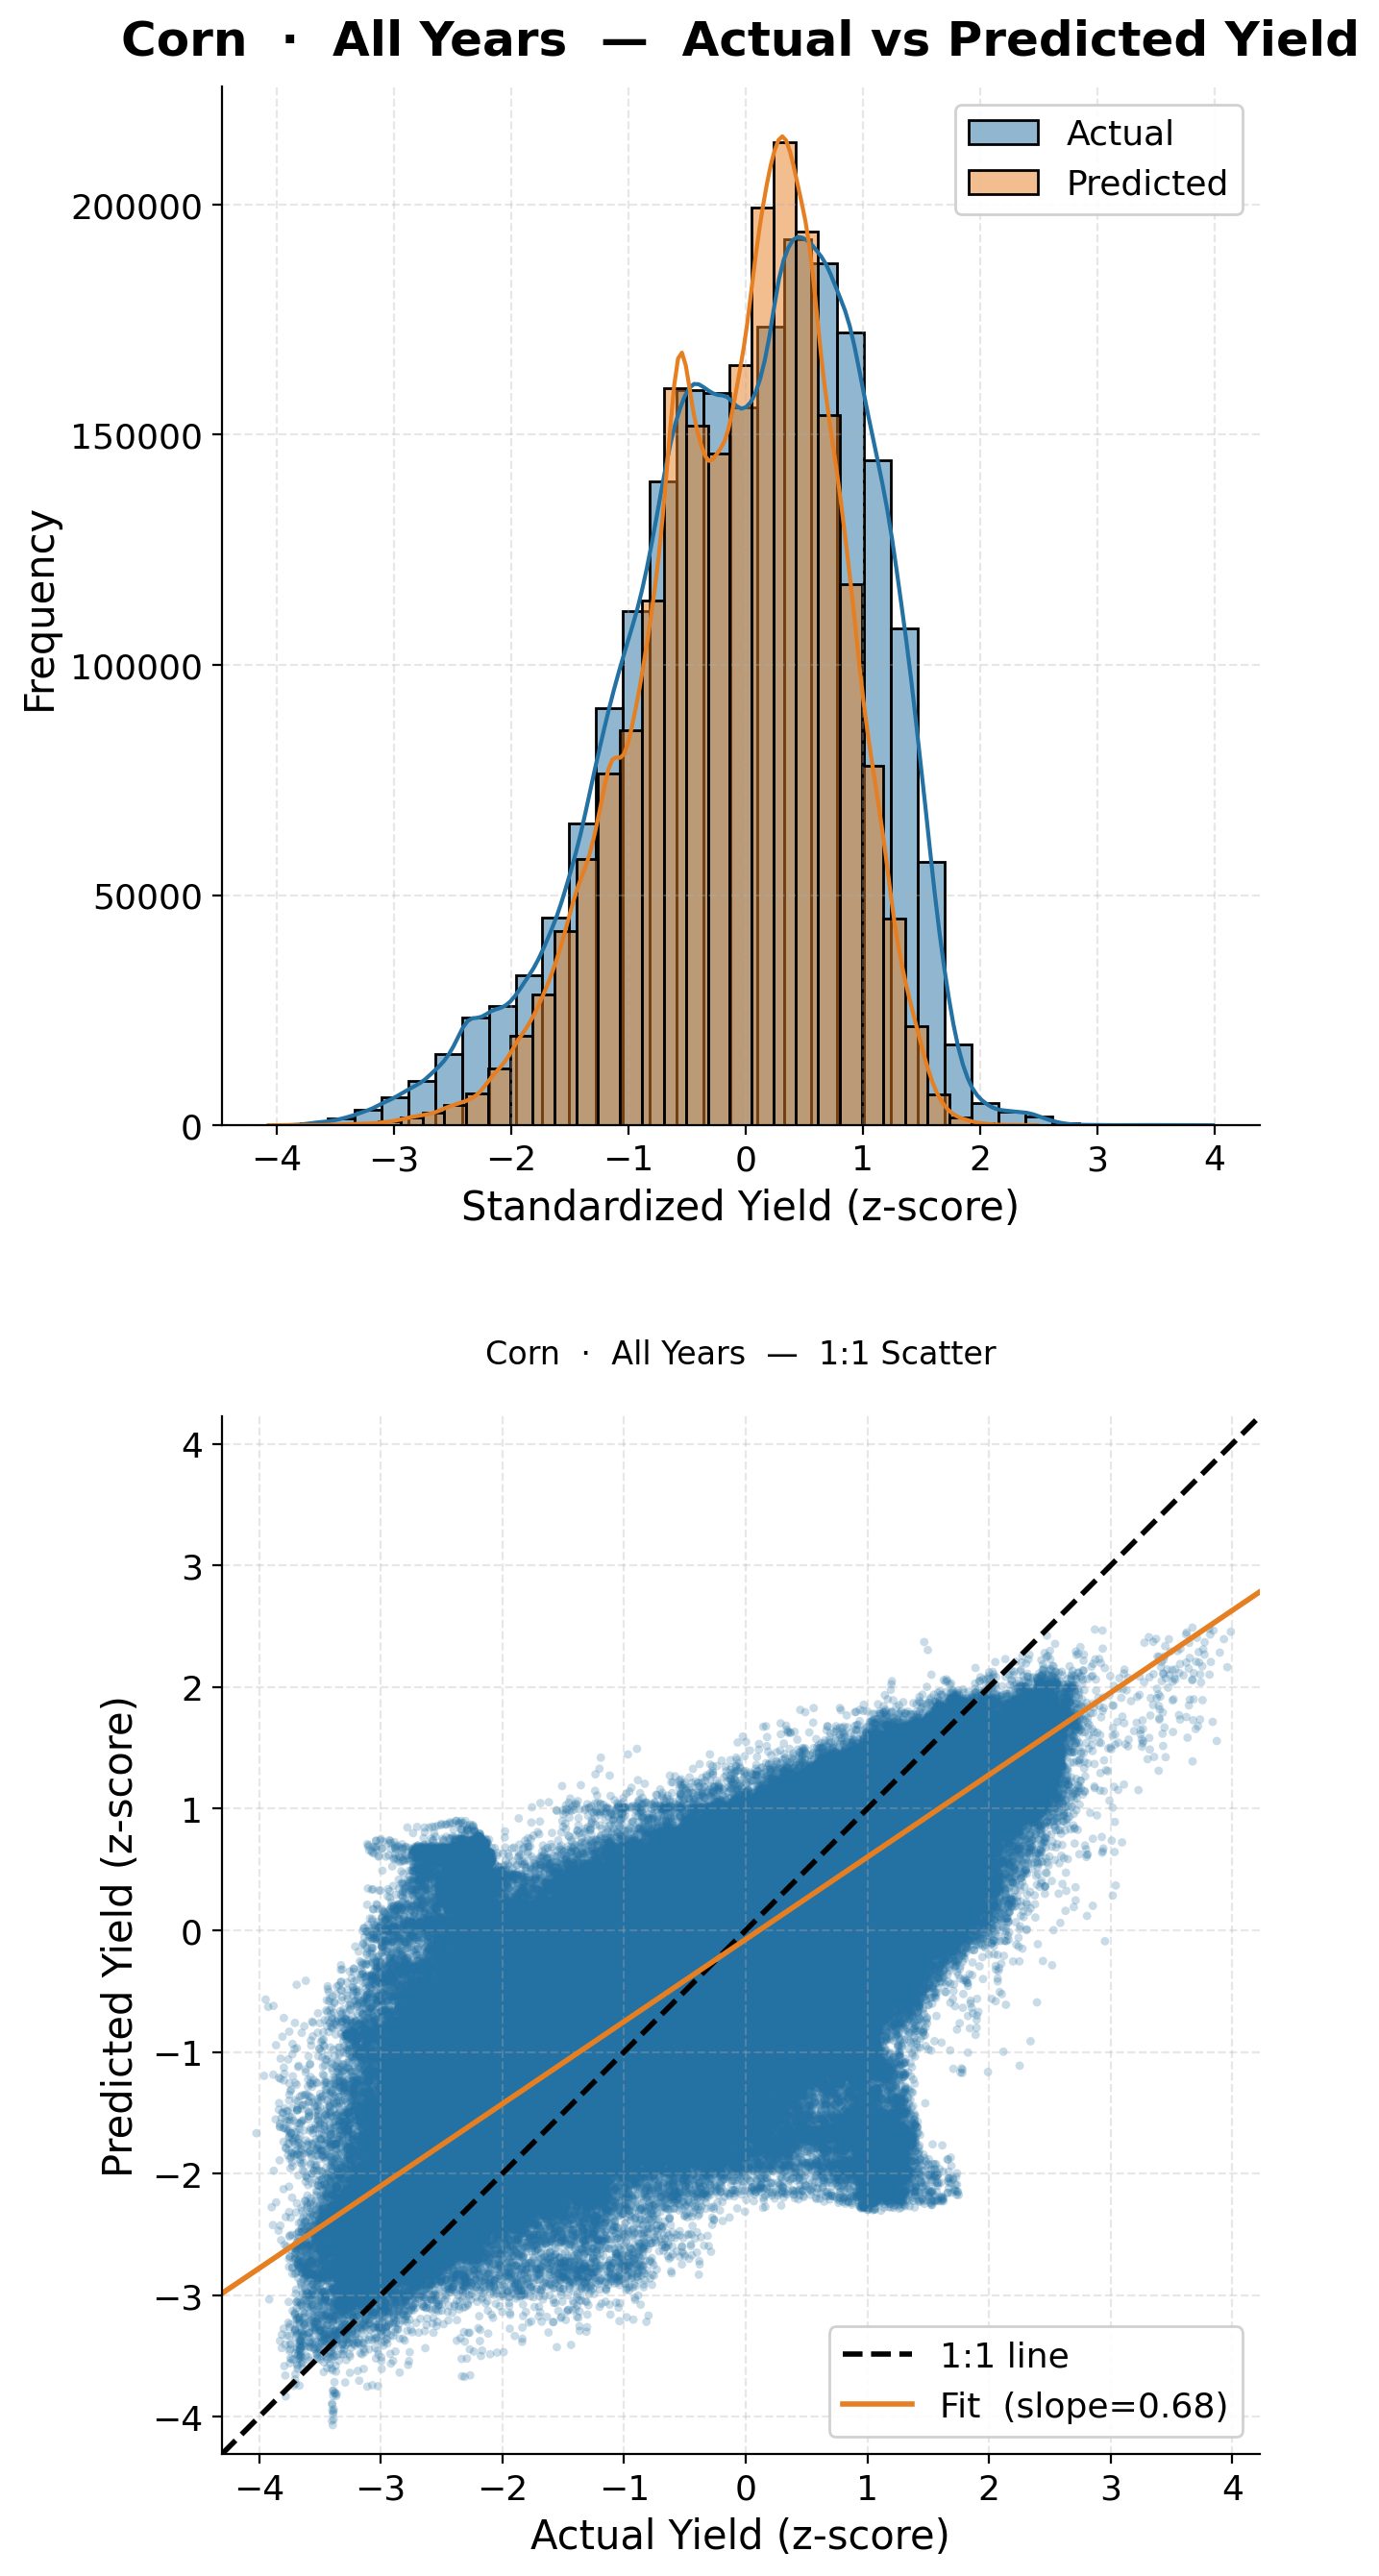

  Wheat | All Years | 495,789 pixels
    R²=0.830  RMSE=9.37  MAE=6.57  Bias=-1.25  Slope=0.775  ZoneAcc=0.744
  Saved → actual_vs_pred_wheat_all_years.png


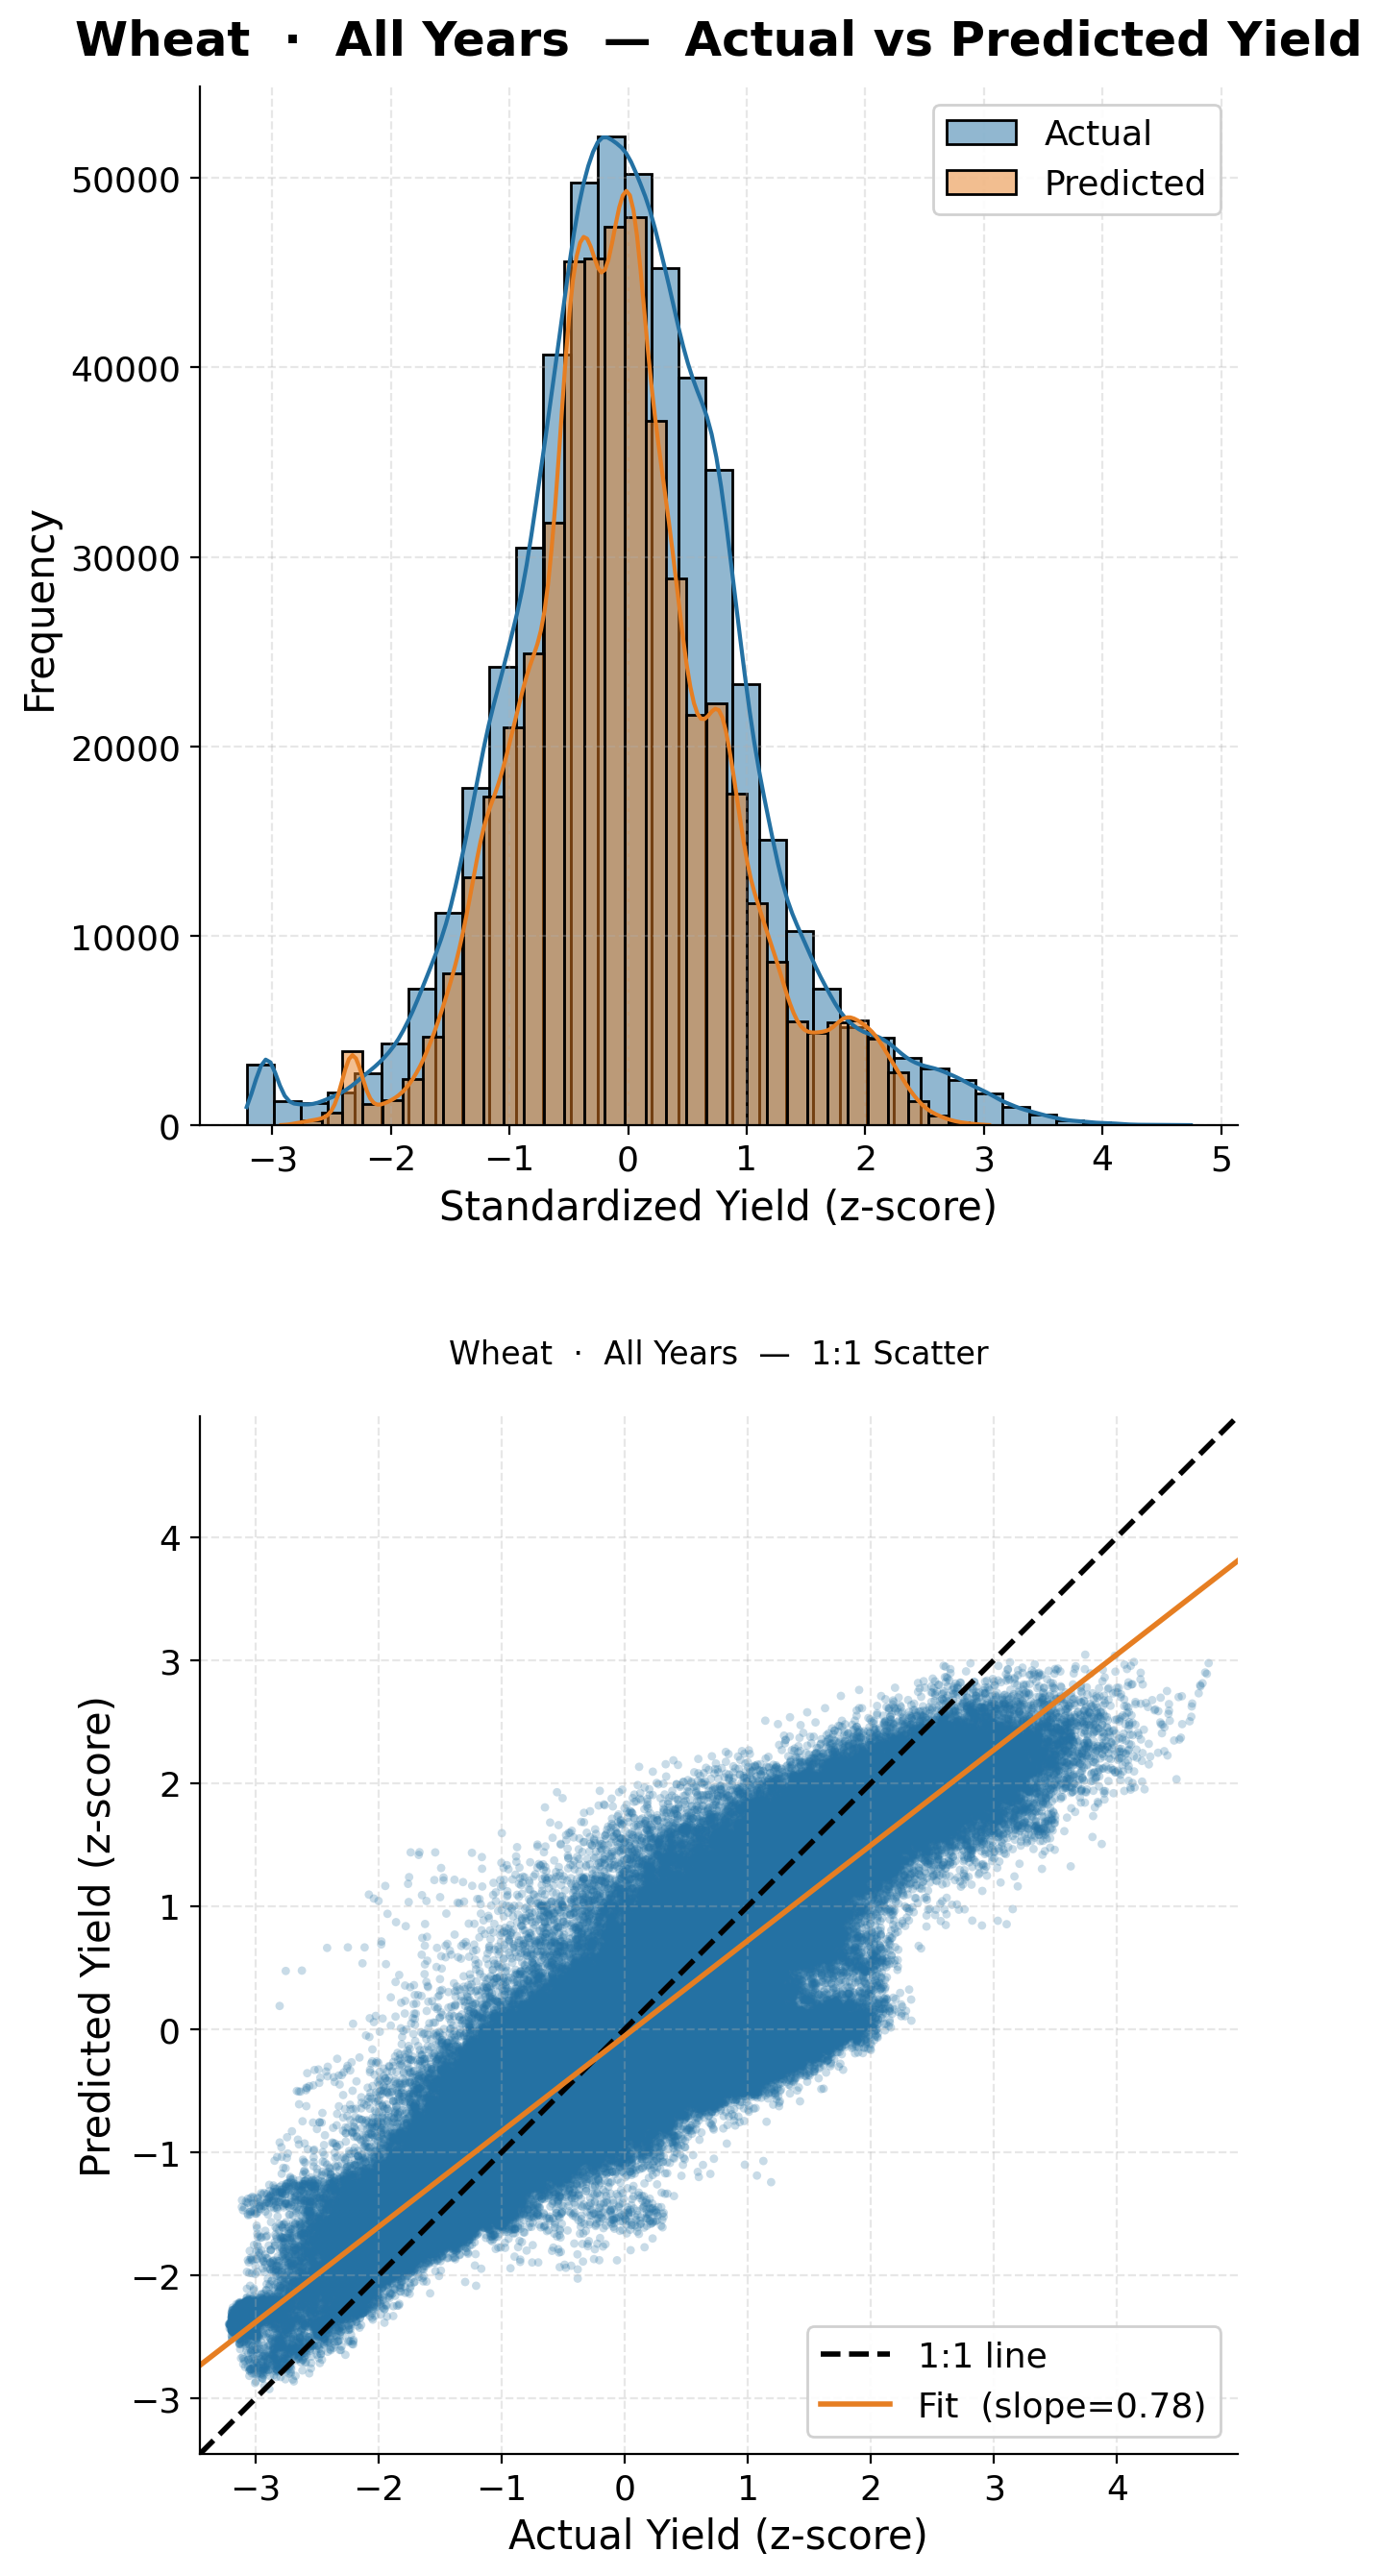

  Soybean | All Years | 694,250 pixels
    R²=0.775  RMSE=6.52  MAE=4.72  Bias=-0.95  Slope=0.746  ZoneAcc=0.702
  Saved → actual_vs_pred_soybean_all_years.png


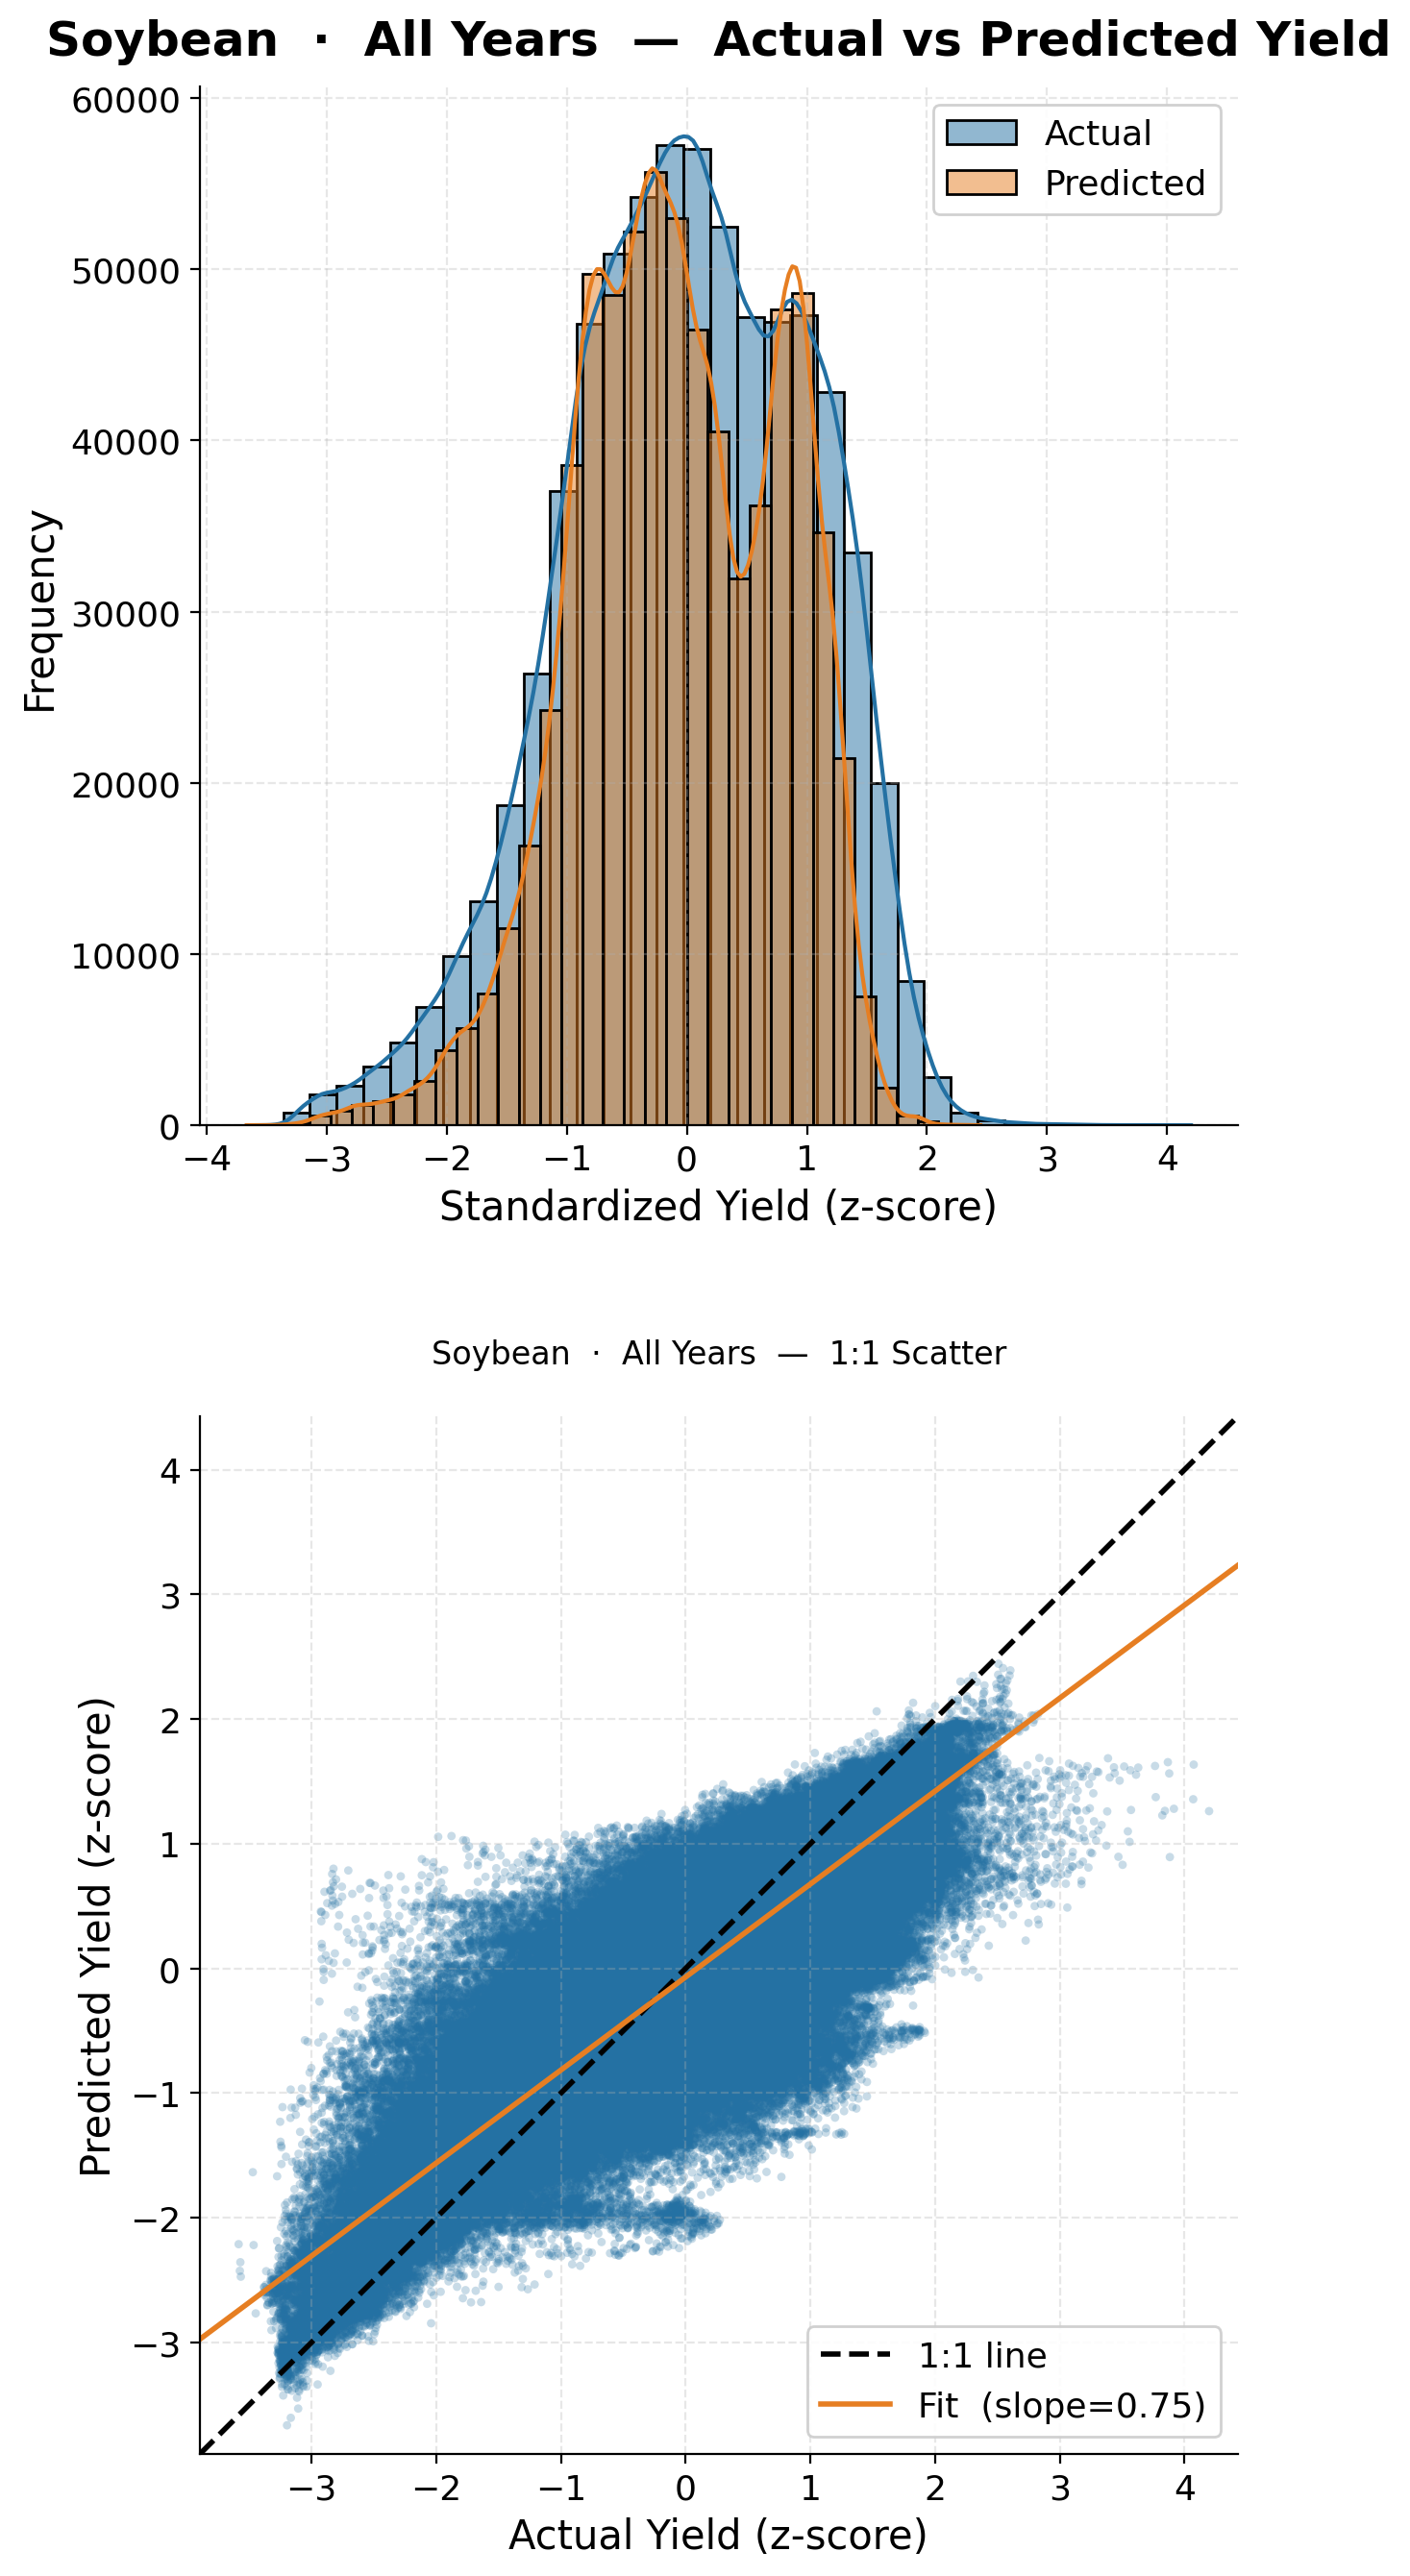

In [12]:
"""
plot_actual_vs_predicted.py
────────────────────────────────────────────────────────────────────────────
Vertical layout: histogram+KDE top, 1:1 scatter bottom.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


def plot_actual_vs_predicted(
    df,
    crop,
    year             = None,
    actual_col       = "yield",
    pred_col         = "pred_yield_oof",
    farm_col         = "farm_name",
    crop_col         = "crop",
    year_col         = "year",
    figsize          = (10, 16),
    dpi              = 200,
    save_path        = None,
    title_fontsize   = 18,
    label_fontsize   = 15,
    tick_fontsize    = 13,
    legend_fontsize  = 13,
):
    # ── 1. Filter to crop only if the column exists and has multiple crops ─────
    if crop_col in df.columns and df[crop_col].nunique() > 1:
        dfc = df[df[crop_col].astype(str).str.lower() == crop.lower()].copy()
    else:
        dfc = df.copy()   # single-crop parquet — no filtering needed

    # ── 2. Optional single-year filter ───────────────────────────────────────
    year_label = "All Years"
    if year is not None:
        dfc        = dfc[dfc[year_col].astype(int) == int(year)].copy()
        year_label = str(year)

    dfc = dfc.dropna(subset=[actual_col, pred_col])
    print(f"  {crop.capitalize()} | {year_label} | {len(dfc):,} pixels")

    ya = dfc[actual_col].to_numpy(dtype=float)
    yp = dfc[pred_col].to_numpy(dtype=float)

    # ── 3. Metrics ────────────────────────────────────────────────────────────
    r2       = r2_score(ya, yp)
    rmse     = float(np.sqrt(mean_squared_error(ya, yp)))
    mae      = float(mean_absolute_error(ya, yp))
    bias     = float(np.mean(yp - ya))
    yr_mean  = dfc.groupby(year_col)[actual_col].transform("mean").to_numpy()
    ratio_a  = ya / yr_mean
    ratio_p  = yp / yr_mean
    zt       = np.where(ratio_a < 0.9, 0, np.where(ratio_a <= 1.1, 1, 2))
    zp_zones = np.where(ratio_p < 0.9, 0, np.where(ratio_p <= 1.1, 1, 2))
    zone_acc = float((zt == zp_zones).mean())

    # ── 4. Z-score for plotting ───────────────────────────────────────────────
    mu   = ya.mean();  sd = ya.std() or 1.0
    yt_z = (ya - mu) / sd
    yp_z = (yp - mu) / sd
    mask = np.isfinite(yt_z) & np.isfinite(yp_z)
    yt   = yt_z[mask];  ypp = yp_z[mask]
    m, b = np.polyfit(yt, ypp, 1)

    print(f"    R²={r2:.3f}  RMSE={rmse:.2f}  MAE={mae:.2f}  "
          f"Bias={bias:+.2f}  Slope={m:.3f}  ZoneAcc={zone_acc:.3f}")

    # ── 5. Figure ─────────────────────────────────────────────────────────────
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=figsize, dpi=dpi,
                                   facecolor="white")
    fig.subplots_adjust(hspace=0.28)

    # TOP: Histogram + KDE
    sns.histplot(yt,  bins=35, color="#2471A3", alpha=0.50,
                 label="Actual",    kde=True, ax=ax0)
    sns.histplot(ypp, bins=35, color="#E67E22", alpha=0.50,
                 label="Predicted", kde=True, ax=ax0)
    ax0.set_title(f"{crop.capitalize()}  ·  {year_label}  —  Actual vs Predicted Yield",
                  fontsize=title_fontsize, fontweight="bold", pad=12)
    ax0.set_xlabel("Standardized Yield (z-score)", fontsize=label_fontsize)
    ax0.set_ylabel("Frequency",                    fontsize=label_fontsize)
    ax0.legend(fontsize=legend_fontsize, framealpha=0.9)
    ax0.grid(alpha=0.3, linestyle="--")
    ax0.tick_params(axis="both", labelsize=tick_fontsize)
    ax0.set_box_aspect(1)
    for sp in ["top", "right"]: ax0.spines[sp].set_visible(False)

    # BOTTOM: 1:1 Scatter
    ax1.scatter(yt, ypp, s=10, alpha=0.25, color="#2471A3",
                edgecolor="none", rasterized=True)
    lo  = min(yt.min(), ypp.min()) - 0.03 * (yt.max() - yt.min())
    hi  = max(yt.max(), ypp.max()) + 0.03 * (yt.max() - yt.min())
    one_to_one, = ax1.plot([lo, hi], [lo, hi],
                           ls="--", lw=2, color="black", label="1:1 line")
    fit_line,   = ax1.plot([lo, hi], [m*lo + b, m*hi + b],
                           lw=2, color="#E67E22",
                           label=f"Fit  (slope={m:.2f})")
    ax1.set_xlim(lo, hi);  ax1.set_ylim(lo, hi)
    ax1.set_aspect("equal", adjustable="box")
    ax1.set_title(f"{crop.capitalize()}  ·  {year_label}  —  1:1 Scatter\n")
    #               f"R²={r2:.3f}  RMSE={rmse:.2f}  Slope={m:.3f}  ZoneAcc={zone_acc:.3f}",
    #               fontsize=title_fontsize - 2, fontweight="bold", pad=12)
    ax1.set_xlabel("Actual Yield (z-score)",    fontsize=label_fontsize)
    ax1.set_ylabel("Predicted Yield (z-score)", fontsize=label_fontsize)
    ax1.grid(alpha=0.3, linestyle="--")
    ax1.tick_params(axis="both", labelsize=tick_fontsize)
    ax1.set_box_aspect(1)
    for sp in ["top", "right"]: ax1.spines[sp].set_visible(False)
    ax1.legend(handles=[one_to_one, fit_line],
               loc="lower right", fontsize=legend_fontsize, framealpha=0.9)

    # Save
    if save_path is None:
        yr_str    = str(year) if year else "all_years"
        save_path = f"actual_vs_pred_{crop.lower()}_{yr_str}.png"
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  Saved → {save_path}")
    plt.show()
    return fig, (ax0, ax1)


# ── RUN ───────────────────────────────────────────────────────────────────────
CROPS = [
    ("corn",    "data/corn_oof_preds.parquet"),
    ("wheat",   "data/wheat_oof_preds.parquet"),
    ("soybean", "data/soybeans_oof_preds.parquet"),
]

for crop_name, parquet_file in CROPS:
    df = pd.read_parquet(parquet_file)
    plot_actual_vs_predicted(
        df, crop=crop_name, year=None,
        actual_col="yield", pred_col="pred_yield_oof",
        farm_col="farm_name", crop_col="crop", year_col="year",
        dpi=200,
    )
    # Single year — uncomment to use:
    # plot_actual_vs_predicted(df, crop=crop_name, year=2020, dpi=200)

In [13]:

# """
# plot_results.py
# ────────────────────────────────────────────────────────────────────────────
# Reads the saved OOF prediction parquets and produces:
#   1. Actual vs Predicted scatter (1:1 plot) per crop  — shows slope
#   2. Histogram / distribution comparison per crop
#   3. Combined summary metrics table (printed)

# Just paste this into a new cell and run. No re-training needed.
# """

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# # ── CONFIG ────────────────────────────────────────────────────────────────────
# PRED_COL  = "pred_yield_oof"
# CROPS = [
#     ("Corn",    "data/corn_oof_preds.parquet"),
#     ("Wheat",   "data/wheat_oof_preds.parquet"),
#     ("Soybean", "data/soybeans_oof_preds.parquet"),
# ]
# COLORS = {"Corn": "#E67E22", "Wheat": "#27AE60", "Soybean": "#2471A3"}

# # ══════════════════════════════════════════════════════════════════════════════
# # 1.  PER-CROP FIGURE  (histogram top, scatter bottom)
# # ══════════════════════════════════════════════════════════════════════════════
# all_metrics = []

# for crop_name, parquet_path in CROPS:
#     df = pd.read_parquet(parquet_path)
#     df = df[df[PRED_COL].notna()].copy()

#     ya = df["yield"].to_numpy(dtype=float)
#     yp = df[PRED_COL].to_numpy(dtype=float)

#     # ── Normalise to z-scores for plotting ────────────────────────────────────
#     mu = ya.mean();  sd = ya.std() or 1.0
#     yz = (ya - mu) / sd
#     pz = (yp - mu) / sd

#     # ── Metrics ───────────────────────────────────────────────────────────────
#     r2   = r2_score(ya, yp)
#     rmse = float(np.sqrt(mean_squared_error(ya, yp)))
#     mae  = float(mean_absolute_error(ya, yp))
#     mape = float(np.mean(np.abs((ya - yp) / ya)) * 100)
#     slope, intercept = np.polyfit(yz, pz, 1)

#     # Zone accuracy  (ratio < 0.9 → low, 0.9-1.1 → normal, > 1.1 → high)
#     yr_mean = df.groupby("year")["yield"].transform("mean")
#     ratio_a = ya / yr_mean.to_numpy()
#     ratio_p = yp / yr_mean.to_numpy()
#     zt = np.where(ratio_a < 0.9, 0, np.where(ratio_a <= 1.1, 1, 2))
#     zp_cls = np.where(ratio_p < 0.9, 0, np.where(ratio_p <= 1.1, 1, 2))
#     zone_acc = (zt == zp_cls).mean()

#     all_metrics.append(dict(Crop=crop_name, R2=r2, RMSE=rmse,
#                             MAE=mae, MAPE=mape, Slope=slope,
#                             ZoneAcc=zone_acc))

#     col = COLORS[crop_name]
#     lo  = min(yz.min(), pz.min()) - 0.1
#     hi  = max(yz.max(), pz.max()) + 0.1

#     fig = plt.figure(figsize=(12, 6), facecolor="white")
#     gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

#     # ── LEFT: histogram ───────────────────────────────────────────────────────
#     ax0 = fig.add_subplot(gs[0])
#     bins = np.linspace(min(yz.min(), pz.min()), max(yz.max(), pz.max()), 50)
#     ax0.hist(yz, bins=bins, alpha=0.5, color="#2471A3", label="Actual",  density=True)
#     ax0.hist(pz, bins=bins, alpha=0.5, color=col,       label="Predicted", density=True)

#     # KDE overlay
#     from scipy.stats import gaussian_kde
#     xg = np.linspace(bins[0], bins[-1], 300)
#     ax0.plot(xg, gaussian_kde(yz)(xg),  color="#2471A3", lw=2)
#     ax0.plot(xg, gaussian_kde(pz)(xg),  color=col,       lw=2)

#     ax0.set_xlabel("Standardised Yield (z-score)", fontsize=12)
#     ax0.set_ylabel("Density", fontsize=12)
#     ax0.set_title(f"{crop_name} — Distribution", fontsize=13, fontweight="bold")
#     ax0.legend(fontsize=10);  ax0.grid(alpha=0.3, linestyle="--")
#     for sp in ["top","right"]: ax0.spines[sp].set_visible(False)

#     # ── RIGHT: 1:1 scatter ────────────────────────────────────────────────────
#     ax1 = fig.add_subplot(gs[1])
#     ax1.scatter(yz, pz, s=3, alpha=0.12, color="#2471A3",
#                 rasterized=True, label="_nolegend_")
#     ax1.plot([lo, hi], [lo, hi],
#              "k--", lw=1.5, label="1:1 ideal")
#     ax1.plot([lo, hi], [slope*lo + intercept, slope*hi + intercept],
#              color=col, lw=2.5, label=f"Fit  slope={slope:.3f}")

#     ax1.set_xlim(lo, hi);  ax1.set_ylim(lo, hi)
#     ax1.set_aspect("equal")
#     ax1.set_xlabel("Actual Yield (z-score)",    fontsize=12)
#     ax1.set_ylabel("Predicted Yield (z-score)", fontsize=12)
#     ax1.set_title(f"{crop_name} — 1:1 Scatter\n"
#                   f"R²={r2:.3f}  RMSE={rmse:.2f}  Slope={slope:.3f}  ZoneAcc={zone_acc:.3f}",
#                   fontsize=12, fontweight="bold")
#     ax1.legend(fontsize=10);  ax1.grid(alpha=0.3, linestyle="--")
#     for sp in ["top","right"]: ax1.spines[sp].set_visible(False)

#     fig.suptitle(f"{crop_name}  —  Out-of-Fold Predictions  "
#                  f"({len(df):,} pixels, all years)",
#                  fontsize=14, fontweight="bold", y=1.01)
#     plt.tight_layout()

#     save_name = f"fig_{crop_name.lower()}_actual_vs_pred.png"
#     fig.savefig(save_name, dpi=200, bbox_inches="tight", facecolor="white")
#     print(f"Saved → {save_name}")
#     plt.show()

# # ══════════════════════════════════════════════════════════════════════════════
# # 2.  COMBINED 3-CROP SCATTER FIGURE  (one panel per crop, side by side)
# # ══════════════════════════════════════════════════════════════════════════════
# fig2, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor="white")
# fig2.suptitle("Actual vs Predicted Yield — All Crops (Out-of-Fold)",
#               fontsize=14, fontweight="bold")

# for ax, (crop_name, parquet_path) in zip(axes, CROPS):
#     df  = pd.read_parquet(parquet_path)
#     df  = df[df[PRED_COL].notna()]
#     ya  = df["yield"].to_numpy(dtype=float)
#     yp  = df[PRED_COL].to_numpy(dtype=float)
#     mu  = ya.mean();  sd = ya.std() or 1.0
#     yz  = (ya - mu) / sd
#     pz  = (yp - mu) / sd
#     m, b = np.polyfit(yz, pz, 1)
#     r2   = r2_score(ya, yp)
#     lo   = min(yz.min(), pz.min()) - 0.1
#     hi   = max(yz.max(), pz.max()) + 0.1
#     col  = COLORS[crop_name]

#     ax.scatter(yz, pz, s=2, alpha=0.1, color="#2471A3", rasterized=True)
#     ax.plot([lo, hi], [lo, hi],          "k--", lw=1.5, label="1:1")
#     ax.plot([lo, hi], [m*lo+b, m*hi+b],  color=col, lw=2.5,
#             label=f"slope={m:.3f}")
#     ax.set_xlim(lo, hi);  ax.set_ylim(lo, hi)
#     ax.set_aspect("equal")
#     ax.set_xlabel("Actual (z-score)",    fontsize=11)
#     ax.set_ylabel("Predicted (z-score)", fontsize=11)
#     ax.set_title(f"{crop_name}\nR²={r2:.3f}  slope={m:.3f}",
#                  fontsize=12, fontweight="bold")
#     ax.legend(fontsize=9);  ax.grid(alpha=0.3, linestyle="--")
#     for sp in ["top","right"]: ax.spines[sp].set_visible(False)

# plt.tight_layout()
# fig2.savefig("fig_all_crops_scatter.png", dpi=200, bbox_inches="tight",
#              facecolor="white")
# print("Saved → fig_all_crops_scatter.png")
# plt.show()

# # ══════════════════════════════════════════════════════════════════════════════
# # 3.  SUMMARY TABLE
# # ══════════════════════════════════════════════════════════════════════════════
# res = pd.DataFrame(all_metrics).set_index("Crop")
# print(f"\n{'═'*65}")
# print("  RESULTS SUMMARY")
# print(f"{'═'*65}")
# print(res.round(4).to_string())
# print(f"{'─'*65}")
# print("  Slope=1.0 is ideal. Baseline was 0.26-0.41. Goal > 0.7")
# print(f"{'═'*65}")

In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

CROPS = [
    ("Corn",    "data/corn_oof_preds.parquet"),
    ("Wheat",   "data/wheat_oof_preds.parquet"),
    ("Soybean", "data/soybeans_oof_preds.parquet"),
]

print(f"\n{'═'*60}")
print(f"  {'Crop':<10} {'R²':>8} {'MAE':>8} {'NRMSE':>8} {'MAPE':>8}")
print(f"  {'─'*50}")

for crop_name, path in CROPS:
    df   = pd.read_parquet(path)
    df   = df[df["pred_yield_oof"].notna()]
    ya   = df["yield"].to_numpy(dtype=float)
    yp   = df["pred_yield_oof"].to_numpy(dtype=float)

    r2   = r2_score(ya, yp)
    mae  = mean_absolute_error(ya, yp)
    rmse = float(np.sqrt(np.mean((ya - yp) ** 2)))
    nrmse = rmse / (ya.max() - ya.min()) * 100   # as %
    mape  = float(np.mean(np.abs((ya - yp) / ya)) * 100)

    print(f"  {crop_name:<10} {r2:>8.4f} {mae:>8.2f} {nrmse:>7.2f}% {mape:>7.2f}%")

print(f"  {'─'*50}")


════════════════════════════════════════════════════════════
  Crop             R²      MAE    NRMSE     MAPE
  ──────────────────────────────────────────────────
  Corn         0.7076    18.08    6.75%   11.61%
  Wheat        0.8296     6.57    5.19%   10.33%
  Soybean      0.7753     4.72    6.09%   10.53%
  ──────────────────────────────────────────────────


# Cut Off Calculation 

In [3]:
"""
zone_cutoffs.py
─────────────────────────────────────────────────────
Prints (and saves) the Low/High zone cutoff values for
each crop × year, based on the same logic used in training:

    zone_mean  = dataset-wide mean yield for that year
    Low  cutoff = zone_mean × 0.9
    High cutoff = zone_mean × 1.1
"""

import pandas as pd

CROPS = [
    ("Corn",    "data/corn_oof_preds.parquet"),
    ("Wheat",   "data/wheat_oof_preds.parquet"),
    ("Soybean", "data/soybeans_oof_preds.parquet"),
]

all_rows = []

for crop_name, path in CROPS:
    df = pd.read_parquet(path, columns=["year", "yield"])

    year_means = df.groupby("year")["yield"].mean()

    print(f"\n{'─'*52}")
    print(f"  {crop_name}")
    print(f"{'─'*52}")
    print(f"  {'Year':>6}  {'Year Mean':>10}  {'Low (<)':>10}  {'High (>)':>10}")
    print(f"  {'':─>6}  {'':─>10}  {'':─>10}  {'':─>10}")

    for year, mean_val in year_means.sort_index().items():
        low  = mean_val * 0.9
        high = mean_val * 1.1
        print(f"  {year:>6}  {mean_val:>10.3f}  {low:>10.3f}  {high:>10.3f}")
        all_rows.append({
            "crop": crop_name,
            "year": year,
            "year_mean": round(mean_val, 4),
            "low_cutoff":  round(low,  4),
            "high_cutoff": round(high, 4),
        })

# # Save to CSV for easy sharing
# out = pd.DataFrame(all_rows)
# out.to_csv("data/zone_cutoffs_by_crop_year.csv", index=False)
# print(f"\n✅ Saved → data/zone_cutoffs_by_crop_year.csv")


────────────────────────────────────────────────────
  Corn
────────────────────────────────────────────────────
    Year   Year Mean     Low (<)    High (>)
  ──────  ──────────  ──────────  ──────────
    2016     180.914     162.823     199.005
    2017     191.549     172.394     210.704
    2018     197.508     177.757     217.259
    2019     196.834     177.150     216.517
    2020     156.872     141.185     172.559
    2021     202.586     182.327     222.845
    2022     185.780     167.202     204.359
    2023     148.967     134.071     163.864

────────────────────────────────────────────────────
  Wheat
────────────────────────────────────────────────────
    Year   Year Mean     Low (<)    High (>)
  ──────  ──────────  ──────────  ──────────
    2016     113.193     101.874     124.512
    2017      81.637      73.473      89.801
    2018      80.953      72.858      89.049
    2019      68.085      61.276      74.893
    2020      72.085      64.876      79.293
    20

In [2]:
"""
zone_cutoffs.py
─────────────────────────────────────────────────────
Computes the Low/High zone cutoff values for each crop × year
using the FULL dataset (all real rows, train + test combined).

Zone logic (matches training pipeline):
    year_mean  = mean yield of ALL real fields for that crop × year
    Low  < year_mean × 0.9
    Med    year_mean × 0.9  to  year_mean × 1.1
    High > year_mean × 1.1
"""

import pandas as pd

# Full original parquets (all real rows, before any CV splitting)
CROPS = [
    ("Corn",    "data/corn_2016_2023_processed.parquet"),
    ("Wheat",   "data/wheat_2016_2023_processed.parquet"),
    ("Soybean", "data/soybeans_2016_2023_processed.parquet"),
]

all_rows = []

for crop_name, path in CROPS:
    df = pd.read_parquet(path, columns=["Year", "yield"])
    df.columns = [c.lower() for c in df.columns]
    df = df[df["yield"].notna()]

    year_means = df.groupby("year")["yield"].mean()

    print(f"\n{'─'*52}")
    print(f"  {crop_name}  (n={len(df):,} real rows)")
    print(f"{'─'*52}")
    print(f"  {'Year':>6}  {'Year Mean':>10}  {'Low (<)':>10}  {'High (>)':>10}")
    print(f"  {'':─>6}  {'':─>10}  {'':─>10}  {'':─>10}")

    for year, mean_val in year_means.sort_index().items():
        low  = mean_val * 0.9
        high = mean_val * 1.1
        n_yr = (df["year"] == year).sum()
        print(f"  {year:>6}  {mean_val:>10.3f}  {low:>10.3f}  {high:>10.3f}  (n={n_yr:,})")
        all_rows.append({
            "crop":        crop_name,
            "year":        year,
            "n_fields":    int(n_yr),
            "year_mean":   round(mean_val, 4),
            "low_cutoff":  round(low,      4),
            "high_cutoff": round(high,     4),
        })

out = pd.DataFrame(all_rows)
out.to_csv("data/zone_cutoffs_by_crop_year.csv", index=False)
print(f"\n✅ Saved → data/zone_cutoffs_by_crop_year.csv")


────────────────────────────────────────────────────
  Corn  (n=2,108,996 real rows)
────────────────────────────────────────────────────
    Year   Year Mean     Low (<)    High (>)
  ──────  ──────────  ──────────  ──────────
    2016     180.914     162.823     199.005  (n=349,194)
    2017     191.549     172.394     210.704  (n=359,174)
    2018     197.508     177.757     217.259  (n=380,070)
    2019     196.834     177.150     216.517  (n=352,539)
    2020     156.872     141.185     172.559  (n=64,052)
    2021     202.586     182.327     222.845  (n=308,438)
    2022     185.780     167.202     204.359  (n=222,361)
    2023     148.967     134.071     163.864  (n=73,168)

────────────────────────────────────────────────────
  Wheat  (n=495,789 real rows)
────────────────────────────────────────────────────
    Year   Year Mean     Low (<)    High (>)
  ──────  ──────────  ──────────  ──────────
    2016     113.193     101.874     124.512  (n=50,372)
    2017      81.637    

In [5]:
import pandas as pd

for i in pd.read_parquet("data/soybeans_oof_preds.parquet").columns:
    print(i)
  

aspect_deg
crop
dem
farm_name
gdd_04
gdd_05
gdd_06
gdd_07
gdd_08
gdd_09
gdd_10
gdd_season
growing_seasons_n
latitude
longitude
normalized_yield_pct
normalized_yield_z
pixel_id
prcp_04
prcp_05
prcp_06
prcp_07
prcp_08
prcp_09
prcp_10
prcp_season
shape_index
slope_deg
soil_bulk_density
soil_clay
soil_sand
soil_silt
soil_soilorganiccarbon
srad_04
srad_05
srad_06
srad_07
srad_08
srad_09
srad_10
srad_season
vh_0603
vh_0607
vh_0608
vh_0612
vh_0614
vh_0615
vh_0619
vh_0620
vh_0624
vh_0626
vh_0627
vh_0701
vh_0702
vh_0706
vh_0708
vh_0709
vh_0713
vh_0714
vh_0717
vh_0717_2
vh_0720
vh_0721
vh_0725
vh_0726
vh_0729
vh_0729_2
vh_0730
vh_0801
vh_0802
vh_0806
vh_0810
vh_0810_2
vh_0811
vh_0813
vh_0818
vh_0819
vh_0822
vh_0822_2
vh_0823
vh_0825
vh_0825_2
vh_0826
vh_0830
vh_0831
vh_0903
vh_0903_2
vh_0904
vh_0906
vh_0907
vh_0911
vh_0912
vh_0915
vh_0916
vh_0918
vh_0919
vh_0923
vh_0924
vh_0928
vh_0930
vh_1003
vh_1005
vh_1006
vh_1010
vh_1012
vh_1013
vh_1015
vh_1017
vh_1024
vh_1025
vh_1027
vh_1029
vh_1030
vv_0603

In [8]:
pd.read_parquet("data/soybeans_oof_preds.parquet")["pred_fold"].unique()

array([5., 4., 3., 1., 2.])